### 0. Importations

Les bibliothèques nécessaires à l'exploration du corpus sont importées au début du notebook.

* `pandas` permet de charger et manipuler les données ;
* `matplotlib` permet de réaliser les premières visualisations.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### 1. Chargement des données

Le fichier `smart_reviews_raw.csv` contient le corpus brut d'avis clients.

Il est chargé depuis le dossier `data/` afin de conserver une organisation claire entre les données et le notebook.


In [4]:
df = pd.read_csv("../data/smart_review_raw.csv")

df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


### 1.2. Nombre d'avis

Le nombre d'avis correspond au nombre de lignes présentes dans le dataset.

In [5]:
nombre_avis = len(df)

print(f"Le dataset contient {nombre_avis} avis.")

Le dataset contient 1200 avis.


### 1.3. Nombre de colonnes

Le nombre de colonnes permet d'identifier les différentes informations disponibles pour chaque avis.

In [6]:
nombre_colonnes = df.shape[1]

print(f"Le dataset possède {nombre_colonnes} colonnes.")

Le dataset possède 8 colonnes.


### 1.4. Type des colonnes

L'analyse du type de chaque colonne permet de vérifier la nature des données avant de poursuivre leur traitement.

In [7]:
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

### 1.5. Valeurs manquantes

Le nombre de valeurs manquantes est vérifié pour chaque colonne afin d'identifier les éventuels problèmes de qualité du corpus.

In [8]:
valeurs_manquantes = df.isna().sum()

valeurs_manquantes

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

In [ ]:
# exprimees en %

pourcentage_manquant = (df.isna().mean() * 100).round(2)

pourcentage_manquant

id_avis      0.00
date         0.00
source       0.00
produit      0.00
texte        0.42
sentiment    0.00
note         0.00
langue       0.00
dtype: float64

### 1.6. Identification des différents types de texte

Le corpus contient différents types de textes présentant des caractéristiques particulières.

On recherche notamment les textes normaux, vides, contenant une URL, une mention, un hashtag, des emojis, beaucoup de ponctuation, uniquement ou majoritairement en majuscules, ainsi que des répétitions de caractères.

In [10]:
texte = df["texte"].fillna("").astype(str)

exemples = {
    "texte normal": texte[
        (texte.str.strip() != "") &
        ~texte.str.contains(r"https?://|www\.", regex=True) &
        ~texte.str.contains(r"@\w+", regex=True) &
        ~texte.str.contains(r"#\w+", regex=True)
    ],
    "texte vide": texte[texte.str.strip() == ""],
    "texte contenant une URL": texte[
        texte.str.contains(r"https?://|www\.", regex=True)
    ],
    "texte contenant une mention": texte[
        texte.str.contains(r"@\w+", regex=True)
    ],
    "texte contenant un hashtag": texte[
        texte.str.contains(r"#\w+", regex=True)
    ],
    "texte contenant un emoji": texte[
        texte.str.contains(r"[^\x00-\x7F]", regex=True)
    ],
    "beaucoup de ponctuation": texte[
        texte.str.count(r"[!?.,;:]") >= 3
    ],
    "texte en majuscules": texte[
        (texte.str.strip() != "") &
        (texte.str.upper() == texte) &
        texte.str.contains(r"[A-ZÀ-ÖØ-Þ]", regex=True)
    ],
    "répétition de caractères": texte[
        texte.str.contains(r"(.)\1{2,}", regex=True)
    ]
}

for categorie, exemples_trouves in exemples.items():
    print(f"\n--- {categorie} ---")
    
    if exemples_trouves.empty:
        print("Aucun exemple trouvé.")
    else:
        print(exemples_trouves.iloc[0])


--- texte normal ---
Très  bonne  expérience,  simple  et  efficace.

--- texte vide ---


--- texte contenant une URL ---
Produit parfait, rien à signaler. https://example.com/commande/17

--- texte contenant une mention ---
@client Livraison rapide et produit conforme à mes attentes.

--- texte contenant un hashtag ---
Très satisfait de mon achat 👍 #avis

--- texte contenant un emoji ---
Très  bonne  expérience,  simple  et  efficace.

--- beaucoup de ponctuation ---
Produit excellent, je suis très satisfait. !!!

--- texte en majuscules ---
LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.

--- répétition de caractères ---
Produit excellent, je suis très satisfait. !!!


C:\Users\Invite\AppData\Local\Temp\ipykernel_18192\605448104.py:32: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  texte.str.contains(r"(.)\1{2,}", regex=True)


### 1.7. Longueur des textes

Une nouvelle colonne `longueur` est créée afin de mesurer le nombre de caractères de chaque avis.

Les statistiques calculées sont la longueur minimale, la longueur maximale, la moyenne, la médiane ainsi que les quartiles.

In [12]:
df["longueur"] = df["texte"].fillna("").astype(str).str.len()

statistiques_longueur = df["longueur"].describe()

statistiques_longueur

count    1200.000000
mean       48.963333
std        22.350913
min         0.000000
25%        37.000000
50%        48.000000
75%        56.000000
max       636.000000
Name: longueur, dtype: float64

In [ ]:
# afficher

print(f"Longueur minimale : {df['longueur'].min()}")
print(f"Longueur maximale : {df['longueur'].max()}")
print(f"Longueur moyenne : {df['longueur'].mean():.2f}")
print(f"Médiane : {df['longueur'].median()}")
print(f"Premier quartile : {df['longueur'].quantile(0.25)}")
print(f"Troisième quartile : {df['longueur'].quantile(0.75)}")

Longueur minimale : 0
Longueur maximale : 636
Longueur moyenne : 48.96
Médiane : 48.0
Premier quartile : 37.0
Troisième quartile : 56.0


### 1.8. Distribution de la longueur des avis

La distribution des longueurs est visualisée afin d'identifier d'éventuels textes anormalement longs ainsi que la présence de nombreux textes très courts.

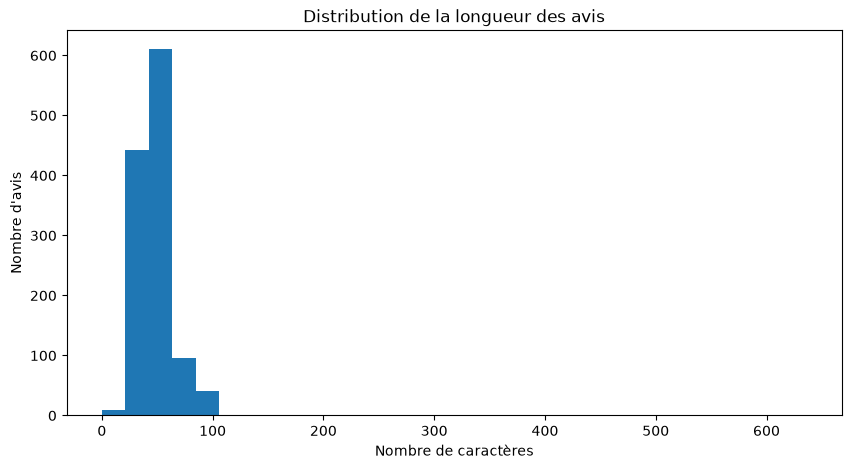

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(df["longueur"], bins=30)

plt.title("Distribution de la longueur des avis")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre d'avis")

plt.show()

In [ ]:
# objectiver les equations avec les quartiles

q1 = df["longueur"].quantile(0.25)
q3 = df["longueur"].quantile(0.75)
iqr = q3 - q1

borne_superieure = q3 + 1.5 * iqr

textes_anormalement_longs = df[df["longueur"] > borne_superieure]
textes_tres_courts = df[df["longueur"] <= q1]

print(f"Nombre de textes anormalement longs : {len(textes_anormalement_longs)}")
print(f"Nombre de textes très courts : {len(textes_tres_courts)}")

Nombre de textes anormalement longs : 41
Nombre de textes très courts : 329


#### a . b. Lecture

La distribution montre que la majorité des avis se concentre sur une plage de longueurs relativement courte. Les valeurs situées au-delà de la borne supérieure calculée sont considérées comme potentiellement anormalement longues.

- peu de texte court
- beaucoup d'avis particulièrement fournis
- donc inclus des textes anormalement longs 

La proportion de textes courts est également examinée afin de déterminer s'ils représentent une part importante du corpus.

### 1.9. Détection des textes vides

Les textes vides sont recherchés après suppression des espaces en début et en fin de chaîne.

In [16]:
textes_vides = df[
    df["texte"].isna() |
    (df["texte"].fillna("").str.strip() == "")
]

print(f"Nombre de textes vides : {len(textes_vides)}")

textes_vides

Nombre de textes vides : 6


,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
46,AV0047,2026-02-24,réseaux_sociaux,SmartWatch Pro,NaN,positif,4,fr,0
108,AV0109,2026-01-24,email,SmartPhone Y,NaN,positif,5,fr,0
310,AV0311,2026-02-13,réseaux_sociaux,Ordinateur NovaBook,NaN,positif,5,fr,0
640,AV0641,2026-08-25,réseaux_sociaux,SmartPhone Y,NaN,positif,5,fr,0
781,AV0782,2026-05-21,email,SmartPhone Y,NaN,neutre,4,fr,0
951,AV0952,2026-06-11,web,Ordinateur NovaBook,,positif,4,fr,3
